In [1]:
!pip install soundfile torchcontrib

  Preparing metadata (setup.py) ... done
  Created wheel for torchcontrib: filename=torchcontrib-0.0.2-py3-none-any.whl size=7516 sha256=f22b25efe8f8b86c0287db2953db684ba5769e7183926387a22e81fdaccdc3ed
  Stored in directory: /root/.cache/pip/wheels/e3/d1/1f/63f00ffea223db446943147a04ff035eb40d00cec3e87d63e5
Successfully built torchcontrib


## Imports
Import all necessary libraries.

In [2]:
import os
import random
import sys
import json
from pathlib import Path
from shutil import copy
from typing import Dict, List, Union
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchcontrib.optim import SWA
from tqdm.notebook import tqdm
import librosa
import soundfile as sf

warnings.filterwarnings("ignore", category=FutureWarning)

2026-04-21 05:06:20.419860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776747980.822207      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776747980.931629      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776747981.937239      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776747981.937285      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776747981.937288      23 computation_placer.cc:177] computation placer alr

## Configuration
Define the configuration for the experiment. This is based on the provided JSON config, updated for the custom dataset and 2-second input length.

In [3]:
config = {
    "database_path": "/kaggle/input/datasets/artharking/asv-19-aa/ASV19",  # Path to the main dataset folder
    "model_path": "/kaggle/working/exp_result/LA_custom_ep5_bs12/weights/best.pth",  # Path to save/load model weights
    "batch_size": 12,
    "num_epochs": 5,
    "target_sr": 16000,
    "loss": "CCE",
    "track": "LA",  # Kept for compatibility, though not used for custom dataset
    "eval_all_best": "True",
    "eval_output": "eval_scores_using_best_dev_model.txt",
    "cudnn_deterministic_toggle": "True",
    "cudnn_benchmark_toggle": "False",
    "model_config": {
        "architecture": "AASIST",
        "nb_samp": 32000,  # 2 seconds at 16kHz
        "first_conv": 128,
        "filts": [70, [1, 32], [32, 32], [32, 64], [64, 64]],
        "gat_dims": [64, 32],
        "pool_ratios": [0.5, 0.7, 0.5, 0.5],
        "temperatures": [2.0, 2.0, 100.0, 100.0]
    },
    "optim_config": {
        "optimizer": "adam",
        "amsgrad": "False",
        "base_lr": 0.0001,
        "lr_min": 0.000005,
        "betas": [0.9, 0.999],
        "weight_decay": 0.0001,
        "scheduler": "cosine",
        "epochs": 5
    }
}

In [4]:
# # RawNet2 Config ... 

# config = {
#     "database_path": "/kaggle/input/datasets/artharking/asv-19-aa/ASV19",
#     "model_path": "/kaggle/working/exp_result/LA_custom_ep5_bs12/weights/best.pth",

#     "batch_size": 12,
#     "num_epochs": 5,
#     "target_sr": 16000,

#     "loss": "CCE",
#     "track": "LA",

#     "eval_all_best": "True",
#     "eval_output": "eval_scores_using_best_dev_model.txt",

#     "cudnn_deterministic_toggle": "True",
#     "cudnn_benchmark_toggle": "False",

#     # =========================
#     # MODEL CONFIG (RAWNET)
#     # =========================
#     "model_config": {
#         "architecture": "RawNet",   # 🔥 changed

#         "nb_samp": 32000,           # 2 sec audio (same)

#         # SincConv
#         "first_conv": 251,          # 🔥 IMPORTANT (not 128)

#         # Filters
#         "filts": [
#             128,        # SincConv out
#             [128, 128], # block0,1
#             [128, 512]  # block2-5
#         ],

#         # GRU
#         "gru_node": 1024,
#         "nb_gru_layer": 1,

#         # FC
#         "nb_fc_node": 1024,
#         "nb_classes": 2
#     },

#     # =========================
#     # OPTIMIZER (UNCHANGED)
#     # =========================
#     "optim_config": {
#         "optimizer": "adam",
#         "amsgrad": "False",
#         "base_lr": 0.0001,
#         "lr_min": 0.000005,
#         "betas": [0.9, 0.999],
#         "weight_decay": 0.0001,
#         "scheduler": "cosine",
#         "epochs": 5
#     }
# }

## Utility Functions
Functions for optimization, scheduling, and reproducibility (from `utils.py`).

In [5]:
import torch
import torch.nn as nn
import numpy as np
import random
import sys

In [6]:


def str_to_bool(val):
    """Convert a string representation of truth to true (1) or false (0)."""
    val = val.lower()
    if val in ('y', 'yes', 't', 'true', 'on', '1'):
        return True
    if val in ('n', 'no', 'f', 'false', 'off', '0'):
        return False
    raise ValueError('invalid truth value {}'.format(val))

def cosine_annealing(step, total_steps, lr_max, lr_min):
    """Cosine Annealing for learning rate decay scheduler"""
    return lr_min + (lr_max - lr_min) * 0.5 * (1 + np.cos(step / total_steps * np.pi))

def keras_decay(step, decay=0.0001):
    """Learning rate decay in Keras-style"""
    return 1. / (1. + decay * step)

class SGDRScheduler(torch.optim.lr_scheduler._LRScheduler):
    """SGD with restarts scheduler"""
    def __init__(self, optimizer, T0, T_mul, eta_min, last_epoch=-1):
        self.Ti = T0
        self.T_mul = T_mul
        self.eta_min = eta_min
        self.last_restart = 0
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        T_cur = self.last_epoch - self.last_restart
        if T_cur >= self.Ti:
            self.last_restart = self.last_epoch
            self.Ti = self.Ti * self.T_mul
            T_cur = 0
        return [self.eta_min + (base_lr - self.eta_min) * (1 + np.cos(np.pi * T_cur / self.Ti)) / 2 for base_lr in self.base_lrs]

def _get_optimizer(model_parameters, optim_config):
    """Defines optimizer according to the given config"""
    optimizer_name = optim_config['optimizer']
    if optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model_parameters, lr=optim_config['base_lr'], momentum=optim_config['momentum'],
                                    weight_decay=optim_config['weight_decay'], nesterov=optim_config['nesterov'])
    elif optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model_parameters, lr=optim_config['base_lr'], betas=optim_config['betas'],
                                     weight_decay=optim_config['weight_decay'], amsgrad=str_to_bool(optim_config['amsgrad']))
    else:
        print('Un-known optimizer', optimizer_name)
        sys.exit()
    return optimizer

def _get_scheduler(optimizer, optim_config):
    """Defines learning rate scheduler according to the given config"""
    if optim_config['scheduler'] == 'multistep':
        scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=optim_config['milestones'], gamma=optim_config['lr_decay'])
    elif optim_config['scheduler'] == 'sgdr':
        scheduler = SGDRScheduler(optimizer, optim_config['T0'],
                                  optim_config['Tmult'], optim_config['lr_min'])
    elif optim_config['scheduler'] == 'cosine':
        total_steps = optim_config['epochs'] * optim_config['steps_per_epoch']
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: cosine_annealing(step, total_steps, 1, optim_config['lr_min'] / optim_config['base_lr']))
    elif optim_config['scheduler'] == 'keras_decay':
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: keras_decay(step))
    else:
        scheduler = None
    return scheduler

def create_optimizer(model_parameters, optim_config):
    """Defines an optimizer and a scheduler"""
    optimizer = _get_optimizer(model_parameters, optim_config)
    scheduler = _get_scheduler(optimizer, optim_config)
    return optimizer, scheduler

def seed_worker(worker_id):
    """Used in generating seed for the worker of torch.utils.data.Dataloader"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def set_seed(seed, config=None):
    """Set initial seed for reproduction"""
    if config is None:
        raise ValueError("config should not be None")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = str_to_bool(config["cudnn_deterministic_toggle"])
        torch.backends.cudnn.benchmark = str_to_bool(config["cudnn_benchmark_toggle"])

def prepare_model(model):
    """Moves model to CUDA and wraps in DataParallel if multiple GPUs available"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    if torch.cuda.device_count() > 1:
        print(f"[INFO] Using {torch.cuda.device_count()} GPUs with DataParallel")
        model = torch.nn.DataParallel(model)

    return model, device


In [7]:
print(torch.cuda.device_count())  # Should return 2
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_name(1))


2
Tesla T4
Tesla T4


## Data Utilities
Functions and classes for loading and preprocessing the custom dataset (from `data_utils.py`, adapted for `.flac` files and 2-second inputs).

In [8]:
def pad(x: np.ndarray, max_len: int = 32000) -> np.ndarray:
    x_len = x.shape[0]
    if x_len >= max_len:
        return x[:max_len]
    num_repeats = (max_len // x_len) + 1
    padded_x = np.tile(x, num_repeats)[:max_len]
    return padded_x

def pad_random(x: np.ndarray, max_len: int = 32000) -> np.ndarray:
    x_len = x.shape[0]
    if x_len >= max_len:
        if x_len == max_len:
            return x  # No need to select a random segment if lengths are equal
        stt = np.random.randint(0, x_len - max_len + 1)  # Ensure valid range
        return x[stt:stt + max_len]
    num_repeats = (max_len // x_len) + 1
    padded_x = np.tile(x, num_repeats)[:max_len]
    return padded_x

class Dataset_Custom(Dataset):
    def __init__(self, base_dir, split='train', target_sr=16000):
        """Custom dataset for loading .flac files from train/val/test folders.
        Args:
            base_dir (str): Path to the main dataset folder (containing train/val/test).
            split (str): One of 'train', 'val', or 'test'.
            target_sr (int): Target sample rate (default: 16000).
        """
        self.base_dir = Path(base_dir) / split
        self.target_sr = target_sr
        self.cut = 32000  # 2 seconds at 16kHz

        # Initialize file lists and labels
        self.file_list = []
        self.labels = {}

        # Load real files (label: 1)
        real_dir = self.base_dir / 'bonafide'
        if real_dir.exists():
            for file in real_dir.glob('*.flac'):
                key = file.stem
                self.file_list.append((key, 'bonafide'))
                self.labels[key] = 1

        # Load fake files (label: 0)
        fake_dir = self.base_dir / 'spoof'
        if fake_dir.exists():
            for file in fake_dir.glob('*.flac'):
                key = file.stem
                self.file_list.append((key, 'spoof'))
                self.labels[key] = 0

        if not self.file_list:
            raise ValueError(f"No .flac files found in {self.base_dir}")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, index):
        max_retries = 5
        retries = 0
        while retries < max_retries:
            key, folder = self.file_list[index]
            file_path = self.base_dir / folder / f"{key}.flac"
            try:
                X, _ = sf.read(str(file_path))
                if len(X.shape) > 1:  # If multi-channel, take first channel
                    X = X[:, 0]
                X_pad = pad_random(X, self.cut)
                if np.max(np.abs(X_pad)) == 0:  # Handle zero arrays
                    raise ValueError(f"Audio file {file_path} is silent or invalid")
                X_pad = X_pad / np.max(np.abs(X_pad))  # Normalize
                x_inp = Tensor(X_pad)
                y = self.labels[key]
                return x_inp, y
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                retries += 1
                index = np.random.randint(len(self.file_list))  # Try a new random index
        raise RuntimeError(f"Failed to load valid data after {max_retries} attempts")
        
    def get_key(self, index):
        key, _ = self.file_list[index]
        return key

## AASIST Model
The AASIST model architecture (from `AASIST.py`), which processes raw audio flaceforms.

- Classic AASIST

In [9]:
# class GraphAttentionLayer(nn.Module):
#     def __init__(self, in_dim, out_dim, **kwargs):
#         super().__init__()
#         self.att_proj = nn.Linear(in_dim, out_dim)
#         self.att_weight = self._init_new_params(out_dim, 1)
#         self.proj_with_att = nn.Linear(in_dim, out_dim)
#         self.proj_without_att = nn.Linear(in_dim, out_dim)
#         self.bn = nn.BatchNorm1d(out_dim)
#         self.input_drop = nn.Dropout(p=0.2)
#         self.act = nn.SELU(inplace=True)
#         self.temp = 1.
#         if "temperature" in kwargs:
#             self.temp = kwargs["temperature"]

#     def forward(self, x):
#         x = self.input_drop(x)
#         att_map = self._derive_att_map(x)
#         x = self._project(x, att_map)
#         x = self._apply_BN(x)
#         x = self.act(x)
#         return x

#     def _pairwise_mul_nodes(self, x):
#         nb_nodes = x.size(1)
#         x = x.unsqueeze(2).expand(-1, -1, nb_nodes, -1)
#         x_mirror = x.transpose(1, 2)
#         return x * x_mirror

#     def _derive_att_map(self, x):
#         att_map = self._pairwise_mul_nodes(x)
#         att_map = torch.tanh(self.att_proj(att_map))
#         att_map = torch.matmul(att_map, self.att_weight)
#         att_map = att_map / self.temp
#         att_map = F.softmax(att_map, dim=-2)
#         return att_map

#     def _project(self, x, att_map):
#         x1 = self.proj_with_att(torch.matmul(att_map.squeeze(-1), x))
#         x2 = self.proj_without_att(x)
#         return x1 + x2

#     def _apply_BN(self, x):
#         org_size = x.size()
#         x = x.view(-1, org_size[-1])
#         x = self.bn(x)
#         x = x.view(org_size)
#         return x

#     def _init_new_params(self, *size):
#         out = nn.Parameter(torch.FloatTensor(*size))
#         nn.init.xavier_normal_(out)
#         return out

# class HtrgGraphAttentionLayer(nn.Module):
#     def __init__(self, in_dim, out_dim, **kwargs):
#         super().__init__()
#         self.proj_type1 = nn.Linear(in_dim, in_dim)
#         self.proj_type2 = nn.Linear(in_dim, in_dim)
#         self.att_proj = nn.Linear(in_dim, out_dim)
#         self.att_projM = nn.Linear(in_dim, out_dim)
#         self.att_weight11 = self._init_new_params(out_dim, 1)
#         self.att_weight22 = self._init_new_params(out_dim, 1)
#         self.att_weight12 = self._init_new_params(out_dim, 1)
#         self.att_weightM = self._init_new_params(out_dim, 1)
#         self.proj_with_att = nn.Linear(in_dim, out_dim)
#         self.proj_without_att = nn.Linear(in_dim, out_dim)
#         self.proj_with_attM = nn.Linear(in_dim, out_dim)
#         self.proj_without_attM = nn.Linear(in_dim, out_dim)
#         self.bn = nn.BatchNorm1d(out_dim)
#         self.input_drop = nn.Dropout(p=0.2)
#         self.act = nn.SELU(inplace=True)
#         self.temp = 1.
#         if "temperature" in kwargs:
#             self.temp = kwargs["temperature"]

#     def forward(self, x1, x2, master=None):
#         num_type1 = x1.size(1)
#         num_type2 = x2.size(1)
#         x1 = self.proj_type1(x1)
#         x2 = self.proj_type2(x2)
#         x = torch.cat([x1, x2], dim=1)
#         if master is None:
#             master = torch.mean(x, dim=1, keepdim=True)
#         x = self.input_drop(x)
#         att_map = self._derive_att_map(x, num_type1, num_type2)
#         master = self._update_master(x, master)
#         x = self._project(x, att_map)
#         x = self._apply_BN(x)
#         x = self.act(x)
#         x1 = x.narrow(1, 0, num_type1)
#         x2 = x.narrow(1, num_type1, num_type2)
#         return x1, x2, master

#     def _update_master(self, x, master):
#         att_map = self._derive_att_map_master(x, master)
#         master = self._project_master(x, master, att_map)
#         return master

#     def _pairwise_mul_nodes(self, x):
#         nb_nodes = x.size(1)
#         x = x.unsqueeze(2).expand(-1, -1, nb_nodes, -1)
#         x_mirror = x.transpose(1, 2)
#         return x * x_mirror

#     def _derive_att_map_master(self, x, master):
#         att_map = x * master
#         att_map = torch.tanh(self.att_projM(att_map))
#         att_map = torch.matmul(att_map, self.att_weightM)
#         att_map = att_map / self.temp
#         att_map = F.softmax(att_map, dim=-2)
#         return att_map

#     def _derive_att_map(self, x, num_type1, num_type2):
#         att_map = self._pairwise_mul_nodes(x)
#         att_map = torch.tanh(self.att_proj(att_map))
#         att_board = torch.zeros_like(att_map[:, :, :, 0]).unsqueeze(-1)
#         att_board[:, :num_type1, :num_type1, :] = torch.matmul(att_map[:, :num_type1, :num_type1, :], self.att_weight11)
#         att_board[:, num_type1:, num_type1:, :] = torch.matmul(att_map[:, num_type1:, num_type1:, :], self.att_weight22)
#         att_board[:, :num_type1, num_type1:, :] = torch.matmul(att_map[:, :num_type1, num_type1:, :], self.att_weight12)
#         att_board[:, num_type1:, :num_type1, :] = torch.matmul(att_map[:, num_type1:, :num_type1, :], self.att_weight12)
#         att_map = att_board
#         att_map = att_map / self.temp
#         att_map = F.softmax(att_map, dim=-2)
#         return att_map

#     def _project(self, x, att_map):
#         x1 = self.proj_with_att(torch.matmul(att_map.squeeze(-1), x))
#         x2 = self.proj_without_att(x)
#         return x1 + x2

#     def _project_master(self, x, master, att_map):
#         x1 = self.proj_with_attM(torch.matmul(att_map.squeeze(-1).unsqueeze(1), x))
#         x2 = self.proj_without_attM(master)
#         return x1 + x2

#     def _apply_BN(self, x):
#         org_size = x.size()
#         x = x.view(-1, org_size[-1])
#         x = self.bn(x)
#         x = x.view(org_size)
#         return x

#     def _init_new_params(self, *size):
#         out = nn.Parameter(torch.FloatTensor(*size))
#         nn.init.xavier_normal_(out)
#         return out

# class GraphPool(nn.Module):
#     def __init__(self, k: float, in_dim: int, p: Union[float, int]):
#         super().__init__()
#         self.k = k
#         self.sigmoid = nn.Sigmoid()
#         self.proj = nn.Linear(in_dim, 1)
#         self.drop = nn.Dropout(p=p) if p > 0 else nn.Identity()
#         self.in_dim = in_dim

#     def forward(self, h):
#         Z = self.drop(h)
#         weights = self.proj(Z)
#         scores = self.sigmoid(weights)
#         new_h = self.top_k_graph(scores, h, self.k)
#         return new_h

#     def top_k_graph(self, scores, h, k):
#         _, n_nodes, n_feat = h.size()
#         n_nodes = max(int(n_nodes * k), 1)
#         _, idx = torch.topk(scores, n_nodes, dim=1)
#         idx = idx.expand(-1, -1, n_feat)
#         h = h * scores
#         h = torch.gather(h, 1, idx)
#         return h

# class CONV(nn.Module):
#     @staticmethod
#     def to_mel(hz):
#         return 2595 * np.log10(1 + hz / 700)

#     @staticmethod
#     def to_hz(mel):
#         return 700 * (10**(mel / 2595) - 1)

#     def __init__(self, out_channels, kernel_size, sample_rate=16000, in_channels=1, stride=1, padding=0, dilation=1, bias=False, groups=1, mask=False):
#         super().__init__()
#         if in_channels != 1:
#             msg = "SincConv only support one input channel (here, in_channels = {%i})" % (in_channels)
#             raise ValueError(msg)
#         self.out_channels = out_channels
#         self.kernel_size = kernel_size
#         self.sample_rate = sample_rate
#         if kernel_size % 2 == 0:
#             self.kernel_size = self.kernel_size + 1
#         self.stride = stride
#         self.padding = padding
#         self.dilation = dilation
#         self.mask = mask
#         if bias:
#             raise ValueError('SincConv does not support bias.')
#         if groups > 1:
#             raise ValueError('SincConv does not support groups.')
#         NFFT = 512
#         f = int(self.sample_rate / 2) * np.linspace(0, 1, int(NFFT / 2) + 1)
#         fmel = self.to_mel(f)
#         fmelmax = np.max(fmel)
#         fmelmin = np.min(fmel)
#         filbandwidthsmel = np.linspace(fmelmin, fmelmax, self.out_channels + 1)
#         filbandwidthsf = self.to_hz(filbandwidthsmel)
#         self.mel = filbandwidthsf
#         self.hsupp = torch.arange(-(self.kernel_size - 1) / 2, (self.kernel_size - 1) / 2 + 1)
#         self.band_pass = torch.zeros(self.out_channels, self.kernel_size)
#         for i in range(len(self.mel) - 1):
#             fmin = self.mel[i]
#             fmax = self.mel[i + 1]
#             hHigh = (2*fmax/self.sample_rate) * np.sinc(2*fmax*self.hsupp/self.sample_rate)
#             hLow = (2*fmin/self.sample_rate) * np.sinc(2*fmin*self.hsupp/self.sample_rate)
#             hideal = hHigh - hLow
#             self.band_pass[i, :] = Tensor(np.hamming(self.kernel_size)) * Tensor(hideal)

#     def forward(self, x, mask=False):
#         band_pass_filter = self.band_pass.clone().to(x.device)
#         if mask:
#             A = np.random.uniform(0, 20)
#             A = int(A)
#             A0 = random.randint(0, band_pass_filter.shape[0] - A)
#             band_pass_filter[A0:A0 + A, :] = 0
#         else:
#             band_pass_filter = band_pass_filter
#         self.filters = (band_pass_filter).view(self.out_channels, 1, self.kernel_size)
#         return F.conv1d(x, self.filters, stride=self.stride, padding=self.padding, dilation=self.dilation, bias=None, groups=1)

# class Residual_block(nn.Module):
#     def __init__(self, nb_filts, first=False):
#         super().__init__()
#         self.first = first
#         if not self.first:
#             self.bn1 = nn.BatchNorm2d(num_features=nb_filts[0])
#         self.conv1 = nn.Conv2d(in_channels=nb_filts[0], out_channels=nb_filts[1], kernel_size=(2, 3), padding=(1, 1), stride=1)
#         self.selu = nn.SELU(inplace=False)
#         self.bn2 = nn.BatchNorm2d(num_features=nb_filts[1])
#         self.conv2 = nn.Conv2d(in_channels=nb_filts[1], out_channels=nb_filts[1], kernel_size=(2, 3), padding=(0, 1), stride=1)
#         if nb_filts[0] != nb_filts[1]:
#             self.downsample = True
#             self.conv_downsample = nn.Conv2d(in_channels=nb_filts[0], out_channels=nb_filts[1], padding=(0, 1), kernel_size=(1, 3), stride=1)
#         else:
#             self.downsample = False
#         self.mp = nn.MaxPool2d((1, 3))

#     def forward(self, x):
#         identity = x
#         if not self.first:
#             out = self.bn1(x)
#             out = self.selu(out)
#         else:
#             out = x
#         out = self.conv1(x)
#         out = self.bn2(out)
#         out = self.selu(out)
#         out = self.conv2(out)
#         if self.downsample:
#             identity = self.conv_downsample(identity)
#         out += identity
#         out = self.mp(out)
#         return out

# class Model(nn.Module):
#     def __init__(self, d_args):
#         super().__init__()
#         self.d_args = d_args
#         filts = d_args["filts"]
#         gat_dims = d_args["gat_dims"]
#         pool_ratios = d_args["pool_ratios"]
#         temperatures = d_args["temperatures"]
#         self.conv_time = CONV(out_channels=filts[0], kernel_size=d_args["first_conv"], in_channels=1)
#         self.first_bn = nn.BatchNorm2d(num_features=1)
#         self.drop = nn.Dropout(0.5, inplace=True)
#         self.drop_way = nn.Dropout(0.2, inplace=True)
#         self.selu = nn.SELU(inplace=False)
#         self.encoder = nn.Sequential(
#             nn.Sequential(Residual_block(nb_filts=filts[1], first=True)),
#             nn.Sequential(Residual_block(nb_filts=filts[2])),
#             nn.Sequential(Residual_block(nb_filts=filts[3])),
#             nn.Sequential(Residual_block(nb_filts=filts[4])),
#             nn.Sequential(Residual_block(nb_filts=filts[4])),
#             nn.Sequential(Residual_block(nb_filts=filts[4])))
#         self.pos_S = nn.Parameter(torch.randn(1, 23, filts[-1][-1]))
#         self.master1 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
#         self.master2 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
#         self.GAT_layer_S = GraphAttentionLayer(filts[-1][-1], gat_dims[0], temperature=temperatures[0])
#         self.GAT_layer_T = GraphAttentionLayer(filts[-1][-1], gat_dims[0], temperature=temperatures[1])
#         self.HtrgGAT_layer_ST11 = HtrgGraphAttentionLayer(gat_dims[0], gat_dims[1], temperature=temperatures[2])
#         self.HtrgGAT_layer_ST12 = HtrgGraphAttentionLayer(gat_dims[1], gat_dims[1], temperature=temperatures[2])
#         self.HtrgGAT_layer_ST21 = HtrgGraphAttentionLayer(gat_dims[0], gat_dims[1], temperature=temperatures[2])
#         self.HtrgGAT_layer_ST22 = HtrgGraphAttentionLayer(gat_dims[1], gat_dims[1], temperature=temperatures[2])
#         self.pool_S = GraphPool(pool_ratios[0], gat_dims[0], 0.3)
#         self.pool_T = GraphPool(pool_ratios[1], gat_dims[0], 0.3)
#         self.pool_hS1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.pool_hT1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.pool_hS2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.pool_hT2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.out_layer = nn.Linear(5 * gat_dims[1], 2)

#     def forward(self, x, Freq_aug=False):
#         x = x.unsqueeze(1)
#         x = self.conv_time(x, mask=Freq_aug)
#         x = x.unsqueeze(dim=1)
#         x = F.max_pool2d(torch.abs(x), (3, 3))
#         x = self.first_bn(x)
#         x = self.selu(x)
#         e = self.encoder(x)
#         e_S, _ = torch.max(torch.abs(e), dim=3)
#         e_S = e_S.transpose(1, 2) + self.pos_S
#         gat_S = self.GAT_layer_S(e_S)
#         out_S = self.pool_S(gat_S)
#         e_T, _ = torch.max(torch.abs(e), dim=2)
#         e_T = e_T.transpose(1, 2)
#         gat_T = self.GAT_layer_T(e_T)
#         out_T = self.pool_T(gat_T)
#         master1 = self.master1.expand(x.size(0), -1, -1)
#         master2 = self.master2.expand(x.size(0), -1, -1)
#         out_T1, out_S1, master1 = self.HtrgGAT_layer_ST11(out_T, out_S, master=self.master1)
#         out_S1 = self.pool_hS1(out_S1)
#         out_T1 = self.pool_hT1(out_T1)
#         out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST12(out_T1, out_S1, master=master1)
#         out_T1 = out_T1 + out_T_aug
#         out_S1 = out_S1 + out_S_aug
#         master1 = master1 + master_aug
#         out_T2, out_S2, master2 = self.HtrgGAT_layer_ST21(out_T, out_S, master=self.master2)
#         out_S2 = self.pool_hS2(out_S2)
#         out_T2 = self.pool_hT2(out_T2)
#         out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST22(out_T2, out_S2, master=master2)
#         out_T2 = out_T2 + out_T_aug
#         out_S2 = out_S2 + out_S_aug
#         master2 = master2 + master_aug
#         out_T1 = self.drop_way(out_T1)
#         out_T2 = self.drop_way(out_T2)
#         out_S1 = self.drop_way(out_S1)
#         out_S2 = self.drop_way(out_S2)
#         master1 = self.drop_way(master1)
#         master2 = self.drop_way(master2)
#         out_T = torch.max(out_T1, out_T2)
#         out_S = torch.max(out_S1, out_S2)
#         master = torch.max(master1, master2)
#         T_max, _ = torch.max(torch.abs(out_T), dim=1)
#         T_avg = torch.mean(out_T, dim=1)
#         S_max, _ = torch.max(torch.abs(out_S), dim=1)
#         S_avg = torch.mean(out_S, dim=1)
#         last_hidden = torch.cat([T_max, T_avg, S_max, S_avg, master.squeeze(1)], dim=1)
#         last_hidden = self.drop(last_hidden)
#         output = self.out_layer(last_hidden)
#         return output

- Bi-Mamba AASIST

In [10]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import random
# from typing import Union


# # --- Mamba Blocks ---
# class MambaBlock(nn.Module):
#     def __init__(self, d_model, d_state=64, d_conv=3, d_expand=2):
#         super().__init__()
#         self.inner_dim = d_model * d_expand
#         self.linear_proj = nn.Linear(d_model, self.inner_dim * 2)
#         self.conv = nn.Conv1d(self.inner_dim, self.inner_dim, kernel_size=d_conv, padding=d_conv // 2, groups=d_expand)
#         self.linear_out = nn.Linear(self.inner_dim, d_model)
#         self.norm = nn.LayerNorm(d_model)

#     def forward(self, x):
#         x_proj = self.linear_proj(x)
#         u, v = x_proj.chunk(2, dim=-1)
#         u = u.transpose(1, 2)
#         u = self.conv(u)
#         u = u.transpose(1, 2)
#         x = self.linear_out(F.silu(u * v))
#         return self.norm(x)

# class BidirectionalMamba(nn.Module):
#     def __init__(self, d_model):
#         super().__init__()
#         self.mamba_forward = MambaBlock(d_model)
#         self.mamba_backward = MambaBlock(d_model)
#         self.fuse = nn.Sequential(
#             nn.Linear(2 * d_model, d_model),
#             nn.SiLU(),
#             nn.Linear(d_model, d_model)
#         )

#     def forward(self, x):
#         x_fwd = self.mamba_forward(x)
#         x_bwd = self.mamba_backward(torch.flip(x, dims=[1]))
#         x_bwd = torch.flip(x_bwd, dims=[1])
#         x = torch.cat([x_fwd, x_bwd], dim=-1)
#         return self.fuse(x)

# # class HtrgMambaBlock(nn.Module):
# #     def __init__(self, in_dim, out_dim):
# #         super().__init__()
# #         self.mamba_1 = BidirectionalMamba(in_dim)
# #         self.mamba_2 = BidirectionalMamba(in_dim)
# #         self.master_update = nn.Sequential(
# #             nn.Linear(in_dim, out_dim),
# #             nn.SiLU(),
# #             nn.Linear(out_dim, out_dim)
# #         )
# #         self.out_proj_1 = nn.Linear(in_dim, out_dim)
# #         self.out_proj_2 = nn.Linear(in_dim, out_dim)
# #         self.norm = nn.LayerNorm(out_dim)

# #     def forward(self, x1, x2, master):
# #         x1_mamba = self.mamba_1(x1)
# #         x2_mamba = self.mamba_2(x2)
# #         x1_out = self.out_proj_1(x1_mamba)
# #         x2_out = self.out_proj_2(x2_mamba)
# #         self.master_proj = nn.Linear(64, out_dim)
# #         master_update = self.master_update((x1_out.mean(1) + x2_out.mean(1)) / 2 + master.squeeze(1))
# #         return self.norm(x1_out), self.norm(x2_out), master_update.unsqueeze(1)
# class HtrgMambaBlock(nn.Module):
#     def __init__(self, in_dim, out_dim, master_dim=None):
#         super().__init__()
#         self.in_dim = in_dim
#         self.out_dim = out_dim
#         self.master_dim = master_dim if master_dim is not None else out_dim

#         self.mamba_1 = BidirectionalMamba(in_dim)
#         self.mamba_2 = BidirectionalMamba(in_dim)

#         self.out_proj_1 = nn.Linear(in_dim, out_dim)
#         self.out_proj_2 = nn.Linear(in_dim, out_dim)

#         # Always project master to out_dim for guaranteed shape match
#         self.master_proj = nn.Linear(self.master_dim, out_dim)

#         self.master_update = nn.Sequential(
#             nn.Linear(out_dim, out_dim),
#             nn.SiLU(),
#             nn.Linear(out_dim, out_dim)
#         )

#         self.norm = nn.LayerNorm(out_dim)

#     def forward(self, x1, x2, master):
#         # x1, x2: [B, T, in_dim]; master: [B, 1, master_dim]
#         x1_mamba = self.mamba_1(x1)
#         x2_mamba = self.mamba_2(x2)

#         x1_out = self.out_proj_1(x1_mamba)  # [B, T, out_dim]
#         x2_out = self.out_proj_2(x2_mamba)

#         branch_avg = (x1_out.mean(1) + x2_out.mean(1)) / 2  # [B, out_dim]
#         master_proj = self.master_proj(master.squeeze(1))   # [B, out_dim]

#         fused = branch_avg + master_proj                    # ✅ Both are [B, out_dim]
#         master_update = self.master_update(fused)           # [B, out_dim]

#         return self.norm(x1_out), self.norm(x2_out), master_update.unsqueeze(1)  # [B, T, out_dim], [B, T, out_dim], [B, 1, out_dim]



# # --- GraphPool ---
# class GraphPool(nn.Module):
#     def __init__(self, k: float, in_dim: int, p: Union[float, int]):
#         super().__init__()
#         self.k = k
#         self.sigmoid = nn.Sigmoid()
#         self.proj = nn.Linear(in_dim, 1)
#         self.drop = nn.Dropout(p=p) if p > 0 else nn.Identity()
#         self.in_dim = in_dim

#     def forward(self, h):
#         Z = self.drop(h)
#         weights = self.proj(Z)
#         scores = self.sigmoid(weights)
#         return self.top_k_graph(scores, h, self.k)

#     def top_k_graph(self, scores, h, k):
#         _, n_nodes, n_feat = h.size()
#         n_nodes = max(int(n_nodes * k), 1)
#         _, idx = torch.topk(scores, n_nodes, dim=1)
#         idx = idx.expand(-1, -1, n_feat)
#         h = h * scores
#         h = torch.gather(h, 1, idx)
#         return h


# # --- CONV: SincConv Filter for Raw Audio ---
# class CONV(nn.Module):
#     @staticmethod
#     def to_mel(hz):
#         return 2595 * np.log10(1 + hz / 700)

#     @staticmethod
#     def to_hz(mel):
#         return 700 * (10**(mel / 2595) - 1)

#     def __init__(self, out_channels, kernel_size, sample_rate=16000, in_channels=1, stride=1, padding=0, dilation=1, bias=False, groups=1, mask=False):
#         super().__init__()
#         if in_channels != 1:
#             raise ValueError("SincConv only supports one input channel.")
#         self.out_channels = out_channels
#         self.kernel_size = kernel_size + 1 if kernel_size % 2 == 0 else kernel_size
#         self.sample_rate = sample_rate
#         self.stride = stride
#         self.padding = padding
#         self.dilation = dilation
#         self.mask = mask
#         self.hsupp = torch.arange(-(self.kernel_size - 1) / 2, (self.kernel_size - 1) / 2 + 1)
#         NFFT = 512
#         f = int(sample_rate / 2) * np.linspace(0, 1, int(NFFT / 2) + 1)
#         fmel = self.to_mel(f)
#         filbandwidthsmel = np.linspace(np.min(fmel), np.max(fmel), out_channels + 1)
#         filbandwidthsf = self.to_hz(filbandwidthsmel)
#         self.mel = filbandwidthsf
#         self.band_pass = torch.zeros(out_channels, self.kernel_size)
#         for i in range(len(self.mel) - 1):
#             fmin = self.mel[i]
#             fmax = self.mel[i + 1]
#             hHigh = (2 * fmax / sample_rate) * np.sinc(2 * fmax * self.hsupp / sample_rate)
#             hLow = (2 * fmin / sample_rate) * np.sinc(2 * fmin * self.hsupp / sample_rate)
#             hideal = hHigh - hLow
#             self.band_pass[i, :] = torch.Tensor(np.hamming(self.kernel_size)) * torch.Tensor(hideal)

#     def forward(self, x, mask=False):
#         band_pass_filter = self.band_pass.clone().to(x.device)
#         if mask:
#             A = int(np.random.uniform(0, 20))
#             A0 = random.randint(0, band_pass_filter.shape[0] - A)
#             band_pass_filter[A0:A0 + A, :] = 0
#         filters = band_pass_filter.view(self.out_channels, 1, self.kernel_size)
#         return F.conv1d(x, filters, stride=self.stride, padding=self.padding, dilation=self.dilation, bias=None)


# # --- Residual CNN Block ---
# class Residual_block(nn.Module):
#     def __init__(self, nb_filts, first=False):
#         super().__init__()
#         self.first = first
#         self.bn1 = nn.BatchNorm2d(nb_filts[0]) if not first else nn.Identity()
#         self.conv1 = nn.Conv2d(nb_filts[0], nb_filts[1], kernel_size=(2, 3), padding=(1, 1))
#         self.bn2 = nn.BatchNorm2d(nb_filts[1])
#         self.selu = nn.SELU(inplace=False)
#         self.conv2 = nn.Conv2d(nb_filts[1], nb_filts[1], kernel_size=(2, 3), padding=(0, 1))
#         self.downsample = (nb_filts[0] != nb_filts[1])
#         self.conv_downsample = nn.Conv2d(nb_filts[0], nb_filts[1], kernel_size=(1, 3), padding=(0, 1)) if self.downsample else nn.Identity()
#         self.mp = nn.MaxPool2d((1, 3))

#     def forward(self, x):
#         identity = x
#         out = self.bn1(x)
#         out = self.selu(out)
#         out = self.conv1(out)
#         out = self.bn2(out)
#         out = self.selu(out)
#         out = self.conv2(out)
#         if self.downsample:
#             identity = self.conv_downsample(identity)
#         out += identity
#         return self.mp(out)


# # --- Full BiMambaAASIST Model ---
# class Model(nn.Module):
#     def __init__(self, d_args):
#         super().__init__()
#         filts = d_args["filts"]
#         gat_dims = d_args["gat_dims"]
#         pool_ratios = d_args["pool_ratios"]
#         self.conv_time = CONV(out_channels=filts[0], kernel_size=d_args["first_conv"], in_channels=1)
#         self.first_bn = nn.BatchNorm2d(1)
#         self.drop = nn.Dropout(0.5, inplace=True)
#         self.drop_way = nn.Dropout(0.2, inplace=True)
#         self.selu = nn.SELU(inplace=False)
#         self.encoder = nn.Sequential(*[Residual_block(nb_filts=f, first=(i == 0)) for i, f in enumerate(filts[1:])])
#         self.pos_S = nn.Parameter(torch.randn(1, 23, filts[-1][-1]))
#         self.master1 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
#         self.master2 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
#         self.GAT_layer_S = BidirectionalMamba(filts[-1][-1])
#         self.GAT_layer_T = BidirectionalMamba(filts[-1][-1])
#         self.HtrgGAT_layer_ST11 = HtrgMambaBlock(gat_dims[0], gat_dims[1], master_dim=gat_dims[0])
#         self.HtrgGAT_layer_ST12 = HtrgMambaBlock(gat_dims[1], gat_dims[1], master_dim=gat_dims[1])
#         self.HtrgGAT_layer_ST21 = HtrgMambaBlock(gat_dims[0], gat_dims[1], master_dim=gat_dims[0])
#         self.HtrgGAT_layer_ST22 = HtrgMambaBlock(gat_dims[1], gat_dims[1], master_dim=gat_dims[1])
#         self.pool_S = GraphPool(pool_ratios[0], gat_dims[0], 0.3)
#         self.pool_T = GraphPool(pool_ratios[1], gat_dims[0], 0.3)
#         self.pool_hS1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.pool_hT1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.pool_hS2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.pool_hT2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
#         self.out_layer = nn.Linear(5 * gat_dims[1], 2)

#     def forward(self, x, Freq_aug=False):
#         x = x.unsqueeze(1)
#         x = self.conv_time(x, mask=Freq_aug)
#         x = x.unsqueeze(1)
#         x = F.max_pool2d(torch.abs(x), (3, 3))
#         x = self.first_bn(x)
#         x = self.selu(x)
#         e = self.encoder(x)
#         e_S, _ = torch.max(torch.abs(e), dim=3)
#         e_S = e_S.transpose(1, 2) + self.pos_S
#         gat_S = self.GAT_layer_S(e_S)
#         out_S = self.pool_S(gat_S)
#         e_T, _ = torch.max(torch.abs(e), dim=2)
#         e_T = e_T.transpose(1, 2)
#         gat_T = self.GAT_layer_T(e_T)
#         out_T = self.pool_T(gat_T)
#         master1 = self.master1.expand(x.size(0), -1, -1)
#         master2 = self.master2.expand(x.size(0), -1, -1)
#         out_T1, out_S1, master1 = self.HtrgGAT_layer_ST11(out_T, out_S, master1)
#         out_S1 = self.pool_hS1(out_S1)
#         out_T1 = self.pool_hT1(out_T1)
#         out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST12(out_T1, out_S1, master1)
#         out_T1 = out_T1 + out_T_aug
#         out_S1 = out_S1 + out_S_aug
#         master1 = master1 + master_aug
#         out_T2, out_S2, master2 = self.HtrgGAT_layer_ST21(out_T, out_S, master2)
#         out_S2 = self.pool_hS2(out_S2)
#         out_T2 = self.pool_hT2(out_T2)
#         out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST22(out_T2, out_S2, master2)
#         out_T2 = out_T2 + out_T_aug
#         out_S2 = out_S2 + out_S_aug
#         master2 = master2 + master_aug
#         out_T = torch.max(self.drop_way(out_T1), self.drop_way(out_T2))
#         out_S = torch.max(self.drop_way(out_S1), self.drop_way(out_S2))
#         master = torch.max(self.drop_way(master1), self.drop_way(master2))
#         T_max, _ = torch.max(torch.abs(out_T), dim=1)
#         T_avg = torch.mean(out_T, dim=1)
#         S_max, _ = torch.max(torch.abs(out_S), dim=1)
#         S_avg = torch.mean(out_S, dim=1)
#         last_hidden = torch.cat([T_max, T_avg, S_max, S_avg, master.squeeze(1)], dim=1)
#         last_hidden = self.drop(last_hidden)
#         return self.out_layer(last_hidden)


- RawNet2

In [11]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import random
# from torch import Tensor


# # =========================
# # SincConv (OPTIMIZED)
# # =========================
# class SincConv(nn.Module):
#     def __init__(self, out_channels, kernel_size, sample_rate=16000):
#         super().__init__()

#         if kernel_size % 2 == 0:
#             kernel_size += 1

#         self.out_channels = out_channels
#         self.kernel_size = kernel_size
#         self.sample_rate = sample_rate

#         # mel init
#         NFFT = 512
#         f = int(sample_rate/2) * np.linspace(0,1,int(NFFT/2)+1)
#         mel = 2595 * np.log10(1 + f/700)

#         mel_points = np.linspace(mel.min(), mel.max(), out_channels+1)
#         hz = 700 * (10**(mel_points/2595) - 1)

#         self.hsupp = torch.arange(-(kernel_size-1)/2, (kernel_size-1)/2+1)
#         self.band_pass = torch.zeros(out_channels, kernel_size)

#         for i in range(out_channels):
#             fmin, fmax = hz[i], hz[i+1]
#             hHigh = (2*fmax/sample_rate)*np.sinc(2*fmax*self.hsupp/sample_rate)
#             hLow = (2*fmin/sample_rate)*np.sinc(2*fmin*self.hsupp/sample_rate)
#             self.band_pass[i,:] = Tensor(np.hamming(kernel_size)) * Tensor(hHigh-hLow)

#     def forward(self, x, mask=False):
#         filters = self.band_pass.clone().to(x.device)

#         if mask:
#             A = int(np.random.uniform(0, 20))
#             A0 = random.randint(0, filters.shape[0]-A)
#             filters[A0:A0+A,:] = 0

#         filters = filters.view(self.out_channels,1,self.kernel_size)
#         return F.conv1d(x, filters)


# # =========================
# # Residual Block (1D)
# # =========================
# class Residual_block(nn.Module):
#     def __init__(self, in_ch, out_ch, first=False):
#         super().__init__()

#         self.first = first
#         if not first:
#             self.bn1 = nn.BatchNorm1d(in_ch)

#         self.lrelu = nn.LeakyReLU(0.3)
#         self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
#         self.bn2 = nn.BatchNorm1d(out_ch)
#         self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)

#         self.downsample = None
#         if in_ch != out_ch:
#             self.downsample = nn.Conv1d(in_ch, out_ch, 1)

#         self.pool = nn.MaxPool1d(3)

#     def forward(self, x):
#         identity = x

#         if not self.first:
#             x = self.lrelu(self.bn1(x))

#         out = self.conv1(x)
#         out = self.lrelu(self.bn2(out))
#         out = self.conv2(out)

#         if self.downsample is not None:
#             identity = self.downsample(identity)

#         out = out + identity
#         out = self.pool(out)
#         return out

# # =========================
# # FINAL MODEL (AASIST STYLE)
# # =========================
# class Model(nn.Module):
#     def __init__(self, d_args):
#         super().__init__()

#         filts = d_args["filts"]

#         self.conv_time = SincConv(
#             out_channels=filts[0],
#             kernel_size=d_args["first_conv"]
#         )

#         self.first_bn = nn.BatchNorm1d(filts[0])
#         self.selu = nn.SELU(inplace=True)

#         # CNN
#         self.block0 = Residual_block(filts[0], filts[1][1], first=True)
#         self.block1 = Residual_block(filts[1][1], filts[1][1])

#         self.block2 = Residual_block(filts[1][1], filts[2][1])
#         self.block3 = Residual_block(filts[2][1], filts[2][1])
#         self.block4 = Residual_block(filts[2][1], filts[2][1])
#         self.block5 = Residual_block(filts[2][1], filts[2][1])

#         self.avgpool = nn.AdaptiveAvgPool1d(1)

#         # Attention
#         def make_att(c):
#             return nn.Sequential(nn.Linear(c, c))

#         self.att0 = make_att(filts[1][1])
#         self.att1 = make_att(filts[1][1])
#         self.att2 = make_att(filts[2][1])
#         self.att3 = make_att(filts[2][1])
#         self.att4 = make_att(filts[2][1])
#         self.att5 = make_att(filts[2][1])

#         self.sig = nn.Sigmoid()

#         # GRU
#         self.bn_before_gru = nn.BatchNorm1d(filts[2][1])

#         self.gru = nn.GRU(
#             input_size=filts[2][1],
#             hidden_size=d_args["gru_node"],
#             num_layers=d_args["nb_gru_layer"],
#             batch_first=True
#         )

#         self.fc1 = nn.Linear(d_args["gru_node"], d_args["nb_fc_node"])
#         self.fc2 = nn.Linear(d_args["nb_fc_node"], d_args["nb_classes"])

#     def _attend(self, x, att_layer):
#         y = self.avgpool(x).squeeze(-1)
#         y = self.sig(att_layer(y)).unsqueeze(-1)
#         return x * y + y   # keep your original behavior

#     def forward(self, x, Freq_aug=False):

#         x = x.unsqueeze(1)

#         x = self.conv_time(x, mask=Freq_aug)
#         x = F.max_pool1d(torch.abs(x), 3)
#         x = self.selu(self.first_bn(x))

#         x = self._attend(self.block0(x), self.att0)
#         x = self._attend(self.block1(x), self.att1)
#         x = self._attend(self.block2(x), self.att2)
#         x = self._attend(self.block3(x), self.att3)
#         x = self._attend(self.block4(x), self.att4)
#         x = self._attend(self.block5(x), self.att5)

#         x = self.selu(self.bn_before_gru(x))

#         x = x.permute(0,2,1)  # (B,T,C)

#         x, _ = self.gru(x)
#         x = x[:, -1, :]

#         x = self.fc1(x)
#         x = self.fc2(x)

#         return x

- FAN-AASIST

In [12]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import random

# # ---------- FAN Blocks ----------

# class FANBlock(nn.Module):
#     def __init__(self, in_dim, out_dim):
#         super().__init__()
#         self.linear_p = nn.Linear(in_dim, out_dim // 4)
#         self.linear_g = nn.Linear(in_dim, out_dim - (out_dim // 2))
#         self.act = nn.GELU()
#         self.gate = nn.Parameter(torch.randn(1))

#     def forward(self, x):
#         p = self.linear_p(x)
#         g = self.act(self.linear_g(x))
#         gate = torch.sigmoid(self.gate)
#         return torch.cat([gate * torch.cos(p), gate * torch.sin(p), (1 - gate) * g], dim=-1)

# # class HtrgFANBlock(nn.Module):
# #     def __init__(self, in_dim, out_dim):
# #         super().__init__()
# #         self.fan1 = FANBlock(in_dim, out_dim)
# #         self.fan2 = FANBlock(in_dim, out_dim)
# #         self.master_proj = nn.Linear(out_dim, out_dim)
# #         self.bn = nn.BatchNorm1d(out_dim)
# #         self.act = nn.SELU(inplace=True)

# class HtrgFANBlock(nn.Module):
#     def __init__(self, in_dim, out_dim):
#         super().__init__()
#         self.fan1 = FANBlock(in_dim, out_dim)
#         self.fan2 = FANBlock(in_dim, out_dim)
#         self.master_proj = nn.Linear(in_dim, out_dim)  
#         self.bn = nn.BatchNorm1d(out_dim)
#         self.act = nn.SELU(inplace=True)
        
#     def forward(self, x1, x2, master=None):
#         x1 = self.fan1(x1)
#         x2 = self.fan2(x2)
#         x = torch.cat([x1, x2], dim=1)

#         if master is None:
#             master = torch.mean(x, dim=1, keepdim=True)
#         master = self.master_proj(master)
#         out = self._apply_BN(x)
#         return x1, x2, master

#     def _apply_BN(self, x):
#         B, N, C = x.shape
#         x = self.bn(x.view(-1, C))
#         return self.act(x.view(B, N, C))

# # ---------- GraphPool and SincConv ----------

# class GraphPool(nn.Module):
#     def __init__(self, k: float, in_dim: int, p: float = 0.3):
#         super().__init__()
#         self.k = k
#         self.sigmoid = nn.Sigmoid()
#         self.proj = nn.Linear(in_dim, 1)
#         self.drop = nn.Dropout(p=p)
#         self.in_dim = in_dim

#     def forward(self, h):
#         Z = self.drop(h)
#         scores = self.sigmoid(self.proj(Z))
#         return self.top_k_graph(scores, h, self.k)

#     def top_k_graph(self, scores, h, k):
#         B, N, C = h.shape
#         K = max(int(N * k), 1)
#         _, idx = torch.topk(scores, K, dim=1)
#         idx = idx.expand(-1, -1, C)
#         h = h * scores
#         return torch.gather(h, 1, idx)

# class CONV(nn.Module):
#     def __init__(self, out_channels, kernel_size, sample_rate=16000, in_channels=1):
#         super().__init__()
#         if in_channels != 1:
#             raise ValueError("SincConv only supports 1 input channel")
#         if kernel_size % 2 == 0:
#             kernel_size += 1
#         self.out_channels = out_channels
#         self.kernel_size = kernel_size
#         self.sample_rate = sample_rate
#         self.hsupp = torch.arange(-(kernel_size - 1) / 2, (kernel_size - 1) / 2 + 1)
#         self.band_pass = self._create_filters()

#     def _create_filters(self):
#         NFFT = 512
#         f = np.linspace(0, self.sample_rate / 2, int(NFFT / 2) + 1)
#         mel = 2595 * np.log10(1 + f / 700)
#         mel_min, mel_max = mel.min(), mel.max()
#         mel_bands = np.linspace(mel_min, mel_max, self.out_channels + 1)
#         hz_bands = 700 * (10**(mel_bands / 2595) - 1)

#         filters = torch.zeros(self.out_channels, self.kernel_size)
#         for i in range(self.out_channels):
#             fmin, fmax = hz_bands[i], hz_bands[i + 1]
#             hHigh = 2*fmax/self.sample_rate * np.sinc(2*fmax*self.hsupp/self.sample_rate)
#             hLow = 2*fmin/self.sample_rate * np.sinc(2*fmin*self.hsupp/self.sample_rate)
#             filters[i] = torch.tensor(np.hamming(self.kernel_size) * (hHigh - hLow))
#         return filters

#     def forward(self, x, mask=False):
#         filt = self.band_pass.clone().to(x.device)
#         if mask:
#             A = random.randint(0, 20)
#             A0 = random.randint(0, filt.shape[0] - A)
#             filt[A0:A0+A] = 0
#         filters = filt.view(self.out_channels, 1, self.kernel_size)
#         return F.conv1d(x, filters, stride=1, padding=0)

# # ---------- Residual Block ----------

# class Residual_block(nn.Module):
#     def __init__(self, nb_filts, first=False):
#         super().__init__()
#         self.first = first
#         self.conv1 = nn.Conv2d(nb_filts[0], nb_filts[1], (2, 3), padding=(1, 1))
#         self.bn2 = nn.BatchNorm2d(nb_filts[1])
#         self.selu = nn.SELU(inplace=True)
#         self.conv2 = nn.Conv2d(nb_filts[1], nb_filts[1], (2, 3), padding=(0, 1))
#         self.mp = nn.MaxPool2d((1, 3))
#         self.downsample = nb_filts[0] != nb_filts[1]
#         if self.downsample:
#             self.conv_downsample = nn.Conv2d(nb_filts[0], nb_filts[1], (1, 3), padding=(0, 1))

#     def forward(self, x):
#         identity = x
#         out = self.conv1(x if self.first else self.selu(x))
#         out = self.selu(self.bn2(out))
#         out = self.conv2(out)
#         if self.downsample:
#             identity = self.conv_downsample(identity)
#         return self.mp(out + identity)

# # ---------- FAN-AASIST Model ----------

# class Model(nn.Module):
#     def __init__(self, d_args):
#         super().__init__()
#         filts, gat_dims = d_args["filts"], d_args["gat_dims"]
#         pool_ratios = d_args["pool_ratios"]
#         self.conv_time = CONV(filts[0], d_args["first_conv"])
#         self.first_bn = nn.BatchNorm2d(1)
#         self.selu = nn.SELU(inplace=True)
#         self.encoder = nn.Sequential(
#             *[Residual_block(f, first=(i==0)) for i, f in enumerate(filts[1:])]
#         )
#         self.pos_S = nn.Parameter(torch.randn(1, 23, filts[-1][-1]))
#         self.master1 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
#         self.master2 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
#         self.GAT_layer_S = FANBlock(filts[-1][-1], gat_dims[0])
#         self.GAT_layer_T = FANBlock(filts[-1][-1], gat_dims[0])
#         self.HtrgGAT_layers = nn.ModuleList([
#             HtrgFANBlock(gat_dims[0], gat_dims[1]),
#             HtrgFANBlock(gat_dims[1], gat_dims[1]),
#             HtrgFANBlock(gat_dims[0], gat_dims[1]),
#             HtrgFANBlock(gat_dims[1], gat_dims[1])
#         ])
#         self.pool_S = GraphPool(pool_ratios[0], gat_dims[0])
#         self.pool_T = GraphPool(pool_ratios[1], gat_dims[0])
#         self.pool_h = nn.ModuleList([
#             GraphPool(pool_ratios[2], gat_dims[1]),
#             GraphPool(pool_ratios[2], gat_dims[1]),
#             GraphPool(pool_ratios[2], gat_dims[1]),
#             GraphPool(pool_ratios[2], gat_dims[1])
#         ])
#         self.out_layer = nn.Linear(5 * gat_dims[1], 2)
#         self.drop = nn.Dropout(0.5)
#         self.drop_way = nn.Dropout(0.2)

#     def forward(self, x, Freq_aug=False):
#         x = x.unsqueeze(1)
#         x = self.conv_time(x, mask=Freq_aug).unsqueeze(1)
#         x = F.max_pool2d(torch.abs(x), (3, 3))
#         x = self.selu(self.first_bn(x))
#         e = self.encoder(x)
#         e_S = torch.max(torch.abs(e), dim=3)[0].transpose(1, 2) + self.pos_S
#         gat_S = self.GAT_layer_S(e_S)
#         out_S = self.pool_S(gat_S)
#         e_T = torch.max(torch.abs(e), dim=2)[0].transpose(1, 2)
#         gat_T = self.GAT_layer_T(e_T)
#         out_T = self.pool_T(gat_T)

#         master1 = self.master1.expand(x.size(0), -1, -1)
#         out_T1, out_S1, master1 = self.HtrgGAT_layers[0](out_T, out_S, master1)
#         out_S1, out_T1 = self.pool_h[0](out_S1), self.pool_h[1](out_T1)
#         T_aug, S_aug, m_aug = self.HtrgGAT_layers[1](out_T1, out_S1, master1)
#         out_T1, out_S1, master1 = out_T1 + T_aug, out_S1 + S_aug, master1 + m_aug

#         master2 = self.master2.expand(x.size(0), -1, -1)
#         out_T2, out_S2, master2 = self.HtrgGAT_layers[2](out_T, out_S, master2)
#         out_S2, out_T2 = self.pool_h[2](out_S2), self.pool_h[3](out_T2)
#         T_aug, S_aug, m_aug = self.HtrgGAT_layers[3](out_T2, out_S2, master2)
#         out_T2, out_S2, master2 = out_T2 + T_aug, out_S2 + S_aug, master2 + m_aug

#         out_T = torch.max(self.drop_way(out_T1), self.drop_way(out_T2))
#         out_S = torch.max(self.drop_way(out_S1), self.drop_way(out_S2))
#         master = torch.max(self.drop_way(master1), self.drop_way(master2))
#         T_max, T_avg = out_T.abs().max(dim=1)[0], out_T.mean(dim=1)
#         S_max, S_avg = out_S.abs().max(dim=1)[0], out_S.mean(dim=1)
#         last_hidden = self.drop(torch.cat([T_max, T_avg, S_max, S_avg, master.squeeze(1)], dim=1))
#         return self.out_layer(last_hidden)


- AASIST 3

In [13]:
# AASIST3 (We would like to thank the authors of AASIST3 (Borodin et. al) for the code and setup) (Code referred from: https://github.com/mtuciru/AASIST3
import random
from typing import Union

import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

#KANLinear
class KANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=10,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.PReLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                # torch.nn.init.constant_(self.spline_scaler, self.scale_spline)
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = (
            self.grid
        )  # (in_features, grid_size + 2 * spline_order + 1)
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(
            0, 1
        )  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        assert x.size(-1) == self.in_features
        original_shape = x.shape
        x = x.reshape(-1, self.in_features)

        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.reshape(self.out_features, -1),
        )
        output = base_output + spline_output
        # print(*original_shape[:-1], output.shape)
        output = output.view(*original_shape[:-1], self.out_features)
        return output

    @torch.no_grad()
    def update_grid(self, x: torch.Tensor, margin=0.01):
        assert x.dim() == 2 and x.size(1) == self.in_features
        batch = x.size(0)

        splines = self.b_splines(x)  # (batch, in, coeff)
        splines = splines.permute(1, 0, 2)  # (in, batch, coeff)
        orig_coeff = self.scaled_spline_weight  # (out, in, coeff)
        orig_coeff = orig_coeff.permute(1, 2, 0)  # (in, coeff, out)
        unreduced_spline_output = torch.bmm(splines, orig_coeff)  # (in, batch, out)
        unreduced_spline_output = unreduced_spline_output.permute(
            1, 0, 2
        )  # (batch, in, out)

        # sort each channel individually to collect data distribution
        x_sorted = torch.sort(x, dim=0)[0]
        grid_adaptive = x_sorted[
            torch.linspace(
                0, batch - 1, self.grid_size + 1, dtype=torch.int64, device=x.device
            )
        ]

        uniform_step = (x_sorted[-1] - x_sorted[0] + 2 * margin) / self.grid_size
        grid_uniform = (
            torch.arange(
                self.grid_size + 1, dtype=torch.float32, device=x.device
            ).unsqueeze(1)
            * uniform_step
            + x_sorted[0]
            - margin
        )

        grid = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        grid = torch.concatenate(
            [
                grid[:1]
                - uniform_step
                * torch.arange(self.spline_order, 0, -1, device=x.device).unsqueeze(1),
                grid,
                grid[-1:]
                + uniform_step
                * torch.arange(1, self.spline_order + 1, device=x.device).unsqueeze(1),
            ],
            dim=0,
        )

        self.grid.copy_(grid.T)

        self.spline_weight.data.copy_(self.curve2coeff(x, unreduced_spline_output))


# AASIST3 
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, **kwargs):
        super().__init__()
        self.att_proj = KANLinear(in_dim, out_dim)
        self.att_weight = self._init_new_params(out_dim, 1)
        self.proj_with_att = KANLinear(in_dim, out_dim)
        self.proj_without_att = KANLinear(in_dim, out_dim)
        self.bn = nn.BatchNorm1d(out_dim)
        self.input_drop = nn.Dropout(p=0.2)
        self.act = nn.SELU(inplace=True)
        self.temp = 1.
        if "temperature" in kwargs:
            self.temp = kwargs["temperature"]

    def forward(self, x):
        x = self.input_drop(x)
        att_map = self._derive_att_map(x)
        x = self._project(x, att_map)
        x = self._apply_BN(x)
        x = self.act(x)
        return x

    def _pairwise_mul_nodes(self, x):
        nb_nodes = x.size(1)
        x = x.unsqueeze(2).expand(-1, -1, nb_nodes, -1)
        x_mirror = x.transpose(1, 2)
        return x * x_mirror

    def _derive_att_map(self, x):
        att_map = self._pairwise_mul_nodes(x)
        att_map = torch.tanh(self.att_proj(att_map))
        att_map = torch.matmul(att_map, self.att_weight)
        att_map = att_map / self.temp
        att_map = F.softmax(att_map, dim=-2)
        return att_map

    def _project(self, x, att_map):
        x1 = self.proj_with_att(torch.matmul(att_map.squeeze(-1), x))
        x2 = self.proj_without_att(x)
        return x1 + x2

    def _apply_BN(self, x):
        org_size = x.size()
        x = x.view(-1, org_size[-1])
        x = self.bn(x)
        x = x.view(org_size)
        return x

    def _init_new_params(self, *size):
        out = nn.Parameter(torch.FloatTensor(*size))
        nn.init.xavier_normal_(out)
        return out

class HtrgGraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, **kwargs):
        super().__init__()
        self.proj_type1 = KANLinear(in_dim, in_dim)
        self.proj_type2 = KANLinear(in_dim, in_dim)
        self.att_proj = KANLinear(in_dim, out_dim)
        self.att_projM = KANLinear(in_dim, out_dim)
        self.att_weight11 = self._init_new_params(out_dim, 1)
        self.att_weight22 = self._init_new_params(out_dim, 1)
        self.att_weight12 = self._init_new_params(out_dim, 1)
        self.att_weightM = self._init_new_params(out_dim, 1)
        self.proj_with_att = KANLinear(in_dim, out_dim)
        self.proj_without_att = KANLinear(in_dim, out_dim)
        self.proj_with_attM = KANLinear(in_dim, out_dim)
        self.proj_without_attM = KANLinear(in_dim, out_dim)
        self.bn = nn.BatchNorm1d(out_dim)
        self.input_drop = nn.Dropout(p=0.2)
        self.act = nn.SELU(inplace=True)
        self.temp = 1.
        if "temperature" in kwargs:
            self.temp = kwargs["temperature"]

    def forward(self, x1, x2, master=None):
        num_type1 = x1.size(1)
        num_type2 = x2.size(1)
        x1 = self.proj_type1(x1)
        x2 = self.proj_type2(x2)
        x = torch.cat([x1, x2], dim=1)
        if master is None:
            master = torch.mean(x, dim=1, keepdim=True)
        x = self.input_drop(x)
        att_map = self._derive_att_map(x, num_type1, num_type2)
        master = self._update_master(x, master)
        x = self._project(x, att_map)
        x = self._apply_BN(x)
        x = self.act(x)
        x1 = x.narrow(1, 0, num_type1)
        x2 = x.narrow(1, num_type1, num_type2)
        return x1, x2, master

    def _update_master(self, x, master):
        att_map = self._derive_att_map_master(x, master)
        master = self._project_master(x, master, att_map)
        return master

    def _pairwise_mul_nodes(self, x):
        nb_nodes = x.size(1)
        x = x.unsqueeze(2).expand(-1, -1, nb_nodes, -1)
        x_mirror = x.transpose(1, 2)
        return x * x_mirror

    def _derive_att_map_master(self, x, master):
        att_map = x * master
        att_map = torch.tanh(self.att_projM(att_map))
        att_map = torch.matmul(att_map, self.att_weightM)
        att_map = att_map / self.temp
        att_map = F.softmax(att_map, dim=-2)
        return att_map

    def _derive_att_map(self, x, num_type1, num_type2):
        att_map = self._pairwise_mul_nodes(x)
        att_map = torch.tanh(self.att_proj(att_map))
        att_board = torch.zeros_like(att_map[:, :, :, 0]).unsqueeze(-1)
        att_board[:, :num_type1, :num_type1, :] = torch.matmul(att_map[:, :num_type1, :num_type1, :], self.att_weight11)
        att_board[:, num_type1:, num_type1:, :] = torch.matmul(att_map[:, num_type1:, num_type1:, :], self.att_weight22)
        att_board[:, :num_type1, num_type1:, :] = torch.matmul(att_map[:, :num_type1, num_type1:, :], self.att_weight12)
        att_board[:, num_type1:, :num_type1, :] = torch.matmul(att_map[:, num_type1:, :num_type1, :], self.att_weight12)
        att_map = att_board
        att_map = att_map / self.temp
        att_map = F.softmax(att_map, dim=-2)
        return att_map

    def _project(self, x, att_map):
        x1 = self.proj_with_att(torch.matmul(att_map.squeeze(-1), x))
        x2 = self.proj_without_att(x)
        return x1 + x2

    def _project_master(self, x, master, att_map):
        x1 = self.proj_with_attM(torch.matmul(att_map.squeeze(-1).unsqueeze(1), x))
        x2 = self.proj_without_attM(master)
        return x1 + x2

    def _apply_BN(self, x):
        org_size = x.size()
        x = x.view(-1, org_size[-1])
        x = self.bn(x)
        x = x.view(org_size)
        return x

    def _init_new_params(self, *size):
        out = nn.Parameter(torch.FloatTensor(*size))
        nn.init.xavier_normal_(out)
        return out

class GraphPool(nn.Module):
    def __init__(self, k: float, in_dim: int, p: Union[float, int]):
        super().__init__()
        self.k = k
        self.sigmoid = nn.Sigmoid()
        self.proj = KANLinear(in_dim, 1)
        self.drop = nn.Dropout(p=p) if p > 0 else nn.Identity()
        self.in_dim = in_dim

    def forward(self, h):
        Z = self.drop(h)
        weights = self.proj(Z)
        scores = self.sigmoid(weights)
        new_h = self.top_k_graph(scores, h, self.k)
        return new_h

    def top_k_graph(self, scores, h, k):
        _, n_nodes, n_feat = h.size()
        n_nodes = max(int(n_nodes * k), 1)
        _, idx = torch.topk(scores, n_nodes, dim=1)
        idx = idx.expand(-1, -1, n_feat)
        h = h * scores
        h = torch.gather(h, 1, idx)
        return h

class CONV(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10**(mel / 2595) - 1)

    def __init__(self, out_channels, kernel_size, sample_rate=16000, in_channels=1, stride=1, padding=0, dilation=1, bias=False, groups=1, mask=False):
        super().__init__()
        if in_channels != 1:
            msg = "SincConv only support one input channel (here, in_channels = {%i})" % (in_channels)
            raise ValueError(msg)
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        if kernel_size % 2 == 0:
            self.kernel_size = self.kernel_size + 1
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        self.mask = mask
        if bias:
            raise ValueError('SincConv does not support bias.')
        if groups > 1:
            raise ValueError('SincConv does not support groups.')
        NFFT = 512
        f = int(self.sample_rate / 2) * np.linspace(0, 1, int(NFFT / 2) + 1)
        fmel = self.to_mel(f)
        fmelmax = np.max(fmel)
        fmelmin = np.min(fmel)
        filbandwidthsmel = np.linspace(fmelmin, fmelmax, self.out_channels + 1)
        filbandwidthsf = self.to_hz(filbandwidthsmel)
        self.mel = filbandwidthsf
        self.hsupp = torch.arange(-(self.kernel_size - 1) / 2, (self.kernel_size - 1) / 2 + 1)
        self.band_pass = torch.zeros(self.out_channels, self.kernel_size)
        for i in range(len(self.mel) - 1):
            fmin = self.mel[i]
            fmax = self.mel[i + 1]
            hHigh = (2*fmax/self.sample_rate) * np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hLow = (2*fmin/self.sample_rate) * np.sinc(2*fmin*self.hsupp/self.sample_rate)
            hideal = hHigh - hLow
            self.band_pass[i, :] = Tensor(np.hamming(self.kernel_size)) * Tensor(hideal)

    def forward(self, x, mask=False):
        band_pass_filter = self.band_pass.clone().to(x.device)
        if mask:
            A = np.random.uniform(0, 20)
            A = int(A)
            A0 = random.randint(0, band_pass_filter.shape[0] - A)
            band_pass_filter[A0:A0 + A, :] = 0
        else:
            band_pass_filter = band_pass_filter
        self.filters = (band_pass_filter).view(self.out_channels, 1, self.kernel_size)
        return F.conv1d(x, self.filters, stride=self.stride, padding=self.padding, dilation=self.dilation, bias=None, groups=1)

class Residual_block(nn.Module):
    def __init__(self, nb_filts, first=False):
        super().__init__()
        self.first = first
        if not self.first:
            self.bn1 = nn.BatchNorm2d(num_features=nb_filts[0])
        self.conv1 = nn.Conv2d(in_channels=nb_filts[0], out_channels=nb_filts[1], kernel_size=(2, 3), padding=(1, 1), stride=1)
        self.selu = nn.SELU(inplace=False)
        self.bn2 = nn.BatchNorm2d(num_features=nb_filts[1])
        self.conv2 = nn.Conv2d(in_channels=nb_filts[1], out_channels=nb_filts[1], kernel_size=(2, 3), padding=(0, 1), stride=1)
        if nb_filts[0] != nb_filts[1]:
            self.downsample = True
            self.conv_downsample = nn.Conv2d(in_channels=nb_filts[0], out_channels=nb_filts[1], padding=(0, 1), kernel_size=(1, 3), stride=1)
        else:
            self.downsample = False
        self.mp = nn.MaxPool2d((1, 3))

    def forward(self, x):
        identity = x
        if not self.first:
            out = self.bn1(x)
            out = self.selu(out)
        else:
            out = x
        out = self.conv1(x)
        out = self.bn2(out)
        out = self.selu(out)
        out = self.conv2(out)
        if self.downsample:
            identity = self.conv_downsample(identity)
        out += identity
        out = self.mp(out)
        return out

class Model(nn.Module):
    def __init__(self, d_args):
        super().__init__()
        self.d_args = d_args
        filts = d_args["filts"]
        gat_dims = d_args["gat_dims"]
        pool_ratios = d_args["pool_ratios"]
        temperatures = d_args["temperatures"]
        self.conv_time = CONV(out_channels=filts[0], kernel_size=d_args["first_conv"], in_channels=1)
        self.first_bn = nn.BatchNorm2d(num_features=1)
        self.drop = nn.Dropout(0.5, inplace=True)
        self.drop_way = nn.Dropout(0.2, inplace=True)
        self.selu = nn.SELU(inplace=False)
        self.encoder = nn.Sequential(
            nn.Sequential(Residual_block(nb_filts=filts[1], first=True)),
            nn.Sequential(Residual_block(nb_filts=filts[2])),
            nn.Sequential(Residual_block(nb_filts=filts[3])),
            nn.Sequential(Residual_block(nb_filts=filts[4])),
            nn.Sequential(Residual_block(nb_filts=filts[4])),
            nn.Sequential(Residual_block(nb_filts=filts[4])))
        self.pos_S = nn.Parameter(torch.randn(1, 23, filts[-1][-1]))
        self.master1 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
        self.master2 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
        self.GAT_layer_S = GraphAttentionLayer(filts[-1][-1], gat_dims[0], temperature=temperatures[0])
        self.GAT_layer_T = GraphAttentionLayer(filts[-1][-1], gat_dims[0], temperature=temperatures[1])
        self.HtrgGAT_layer_ST11 = HtrgGraphAttentionLayer(gat_dims[0], gat_dims[1], temperature=temperatures[2])
        self.HtrgGAT_layer_ST12 = HtrgGraphAttentionLayer(gat_dims[1], gat_dims[1], temperature=temperatures[2])
        self.HtrgGAT_layer_ST21 = HtrgGraphAttentionLayer(gat_dims[0], gat_dims[1], temperature=temperatures[2])
        self.HtrgGAT_layer_ST22 = HtrgGraphAttentionLayer(gat_dims[1], gat_dims[1], temperature=temperatures[2])
        self.pool_S = GraphPool(pool_ratios[0], gat_dims[0], 0.3)
        self.pool_T = GraphPool(pool_ratios[1], gat_dims[0], 0.3)
        self.pool_hS1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
        self.pool_hT1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
        self.pool_hS2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
        self.pool_hT2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
        self.out_layer = KANLinear(5 * gat_dims[1], 2)

    def forward(self, x, Freq_aug=False):
        x = x.unsqueeze(1)
        x = self.conv_time(x, mask=Freq_aug)
        x = x.unsqueeze(dim=1)
        x = F.max_pool2d(torch.abs(x), (3, 3))
        x = self.first_bn(x)
        x = self.selu(x)
        e = self.encoder(x)
        e_S, _ = torch.max(torch.abs(e), dim=3)
        e_S = e_S.transpose(1, 2) + self.pos_S
        gat_S = self.GAT_layer_S(e_S)
        out_S = self.pool_S(gat_S)
        e_T, _ = torch.max(torch.abs(e), dim=2)
        e_T = e_T.transpose(1, 2)
        gat_T = self.GAT_layer_T(e_T)
        out_T = self.pool_T(gat_T)
        master1 = self.master1.expand(x.size(0), -1, -1)
        master2 = self.master2.expand(x.size(0), -1, -1)
        out_T1, out_S1, master1 = self.HtrgGAT_layer_ST11(out_T, out_S, master=self.master1)
        out_S1 = self.pool_hS1(out_S1)
        out_T1 = self.pool_hT1(out_T1)
        out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST12(out_T1, out_S1, master=master1)
        out_T1 = out_T1 + out_T_aug
        out_S1 = out_S1 + out_S_aug
        master1 = master1 + master_aug
        out_T2, out_S2, master2 = self.HtrgGAT_layer_ST21(out_T, out_S, master=self.master2)
        out_S2 = self.pool_hS2(out_S2)
        out_T2 = self.pool_hT2(out_T2)
        out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST22(out_T2, out_S2, master=master2)
        out_T2 = out_T2 + out_T_aug
        out_S2 = out_S2 + out_S_aug
        master2 = master2 + master_aug
        out_T1 = self.drop_way(out_T1)
        out_T2 = self.drop_way(out_T2)
        out_S1 = self.drop_way(out_S1)
        out_S2 = self.drop_way(out_S2)
        master1 = self.drop_way(master1)
        master2 = self.drop_way(master2)
        out_T = torch.max(out_T1, out_T2)
        out_S = torch.max(out_S1, out_S2)
        master = torch.max(master1, master2)
        T_max, _ = torch.max(torch.abs(out_T), dim=1)
        T_avg = torch.mean(out_T, dim=1)
        S_max, _ = torch.max(torch.abs(out_S), dim=1)
        S_avg = torch.mean(out_S, dim=1)
        last_hidden = torch.cat([T_max, T_avg, S_max, S_avg, master.squeeze(1)], dim=1)
        last_hidden = self.drop(last_hidden)
        output = self.out_layer(last_hidden)
        return output

## Evaluation Function
Function to compute Equal Error Rate (EER) using a placeholder `compute_eer` function.

In [14]:
# Placeholder for compute_eer (replace with actual implementation if available)
def compute_eer(target_scores, nontarget_scores):
    """Placeholder for EER computation. Replace with actual implementation."""
    from sklearn.metrics import roc_curve
    import numpy as np
    scores = np.concatenate([target_scores, nontarget_scores])
    labels = np.concatenate([np.ones(len(target_scores)), np.zeros(len(nontarget_scores))])
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer = fpr[np.argmin(np.abs(fpr - fnr))]
    return eer, thresholds[np.argmin(np.abs(fpr - fnr))]

from sklearn.metrics import roc_curve
import numpy as np
import torch
from tqdm import tqdm

def evaluate_full(loader, model, device):
    model.eval()

    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for batch_x, batch_y in tqdm(loader, total=len(loader)):
            batch_x = batch_x.to(device)

            outputs = model(batch_x)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())

    from sklearn.metrics import roc_curve
    import numpy as np

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    return np.array(all_labels), np.array(all_preds), np.array(all_probs), eer

def evaluate(loader, model, device):
    """Keeps compatibility with training loop (returns only EER)"""
    _, _, _, eer = evaluate_full(loader, model, device)
    return eer

## DataLoader
Function to create DataLoaders for the custom dataset.

In [15]:
def get_loader(database_path: str, seed: int, config: dict) -> List[torch.utils.data.DataLoader]:
    """Create DataLoaders for train, validation, and test sets."""
    target_sr = float(config["target_sr"])
    train_set = Dataset_Custom(base_dir=database_path, split='train', target_sr=target_sr)
    val_set = Dataset_Custom(base_dir=database_path, split='dev', target_sr=target_sr)
    test_set = Dataset_Custom(base_dir=database_path, split='test', target_sr=target_sr)

    print(f"No. training files: {len(train_set)}")
    print(f"No. validation files: {len(val_set)}")
    print(f"No. test files: {len(test_set)}")

    gen = torch.Generator()
    gen.manual_seed(seed)
    trn_loader = DataLoader(train_set, batch_size=config["batch_size"], shuffle=True, drop_last=True,
                            pin_memory=True, worker_init_fn=seed_worker, generator=gen, num_workers=4)
    val_loader = DataLoader(val_set, batch_size=config["batch_size"], shuffle=False, drop_last=False,
                            pin_memory=True, num_workers=4)
    test_loader = DataLoader(test_set, batch_size=config["batch_size"], shuffle=False, drop_last=False,
                             pin_memory=True, num_workers=4)
    return trn_loader, val_loader, test_loader

## Training Function
Function to train the model for one epoch.

In [16]:
def train_epoch(trn_loader: DataLoader, model, optim: Union[torch.optim.SGD, torch.optim.Adam],
                device: torch.device, scheduler: torch.optim.lr_scheduler, config: dict):
    """Train the model for one epoch."""
    running_loss = 0
    num_total = 0.0
    model.train()
    weight = torch.FloatTensor([0.1, 0.9]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight)
    pbar = tqdm(trn_loader, total=len(trn_loader))
    for batch_x, batch_y in pbar:
        batch_size = batch_x.size(0)
        num_total += batch_size
        batch_x = batch_x.to(device)
        batch_y = batch_y.view(-1).type(torch.int64).to(device)
        batch_out = model(batch_x)
        batch_loss = criterion(batch_out, batch_y)
        running_loss += batch_loss.item() * batch_size
        pbar.set_description(f"loss: {batch_loss.item():.5f}, running loss: {running_loss / num_total:.5f}")
        optim.zero_grad()
        batch_loss.backward()
        optim.step()
        if config["optim_config"]["scheduler"] in ["cosine", "keras_decay"]:
            scheduler.step()
        elif scheduler is None:
            pass
        else:
            raise ValueError(f"scheduler error, got: {scheduler}")
    running_loss /= num_total
    return running_loss
    

## Main Training and Evaluation Loop
Set up the model, train, and evaluate it.

In [17]:
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter
import torch
import os

# --- Utility: Enable Multi-GPU ---
def prepare_model(model):
    """Moves model to CUDA and wraps in DataParallel if multiple GPUs available"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    if torch.cuda.device_count() > 1:
        print(f"[INFO] Using {torch.cuda.device_count()} GPUs with DataParallel")
        model = torch.nn.DataParallel(model)

    return model, device


# Set random seed
seed = 1234
set_seed(seed, config)

# Define model and move to device
model = Model(config["model_config"])
model, device = prepare_model(model)

nb_params = sum([param.view(-1).size(0) for param in model.parameters()])
print(f"No. model params: {nb_params}")
print(f"Device: {device}")
if str(device) == "cpu":
    print("Warning: Running on CPU, which may be slow!")

# Create directories
output_dir = Path("./exp_result")
model_tag = f"LA_custom_ep{config['num_epochs']}_bs{config['batch_size']}"
model_tag = output_dir / model_tag
model_save_path = model_tag / "weights"
eval_score_path = model_tag / config["eval_output"]
writer = SummaryWriter(model_tag)
os.makedirs(model_save_path, exist_ok=True)

# DataLoaders
trn_loader, val_loader, _ = get_loader(config["database_path"], seed, config)

# Optimizer and Scheduler
config["optim_config"]["steps_per_epoch"] = len(trn_loader)
optimizer, scheduler = create_optimizer(model.parameters(), config["optim_config"])
optimizer_swa = SWA(optimizer)

# Training loop
best_val_eer = 1.0
n_swa_update = 0
f_log = open(model_tag / "metric_log.txt", "a")
f_log.write("=" * 5 + "\n")

for epoch in range(config["num_epochs"]):
    print(f"Start training epoch {epoch:03d}")
    running_loss = train_epoch(trn_loader, model, optimizer, device, scheduler, config)

    # Only train + val EER during training
    # train_eer = evaluate(trn_loader, model, device)
    val_eer = evaluate(val_loader, model, device)

    print(f"DONE.\nLoss: {running_loss:.5f}, "
          # f"train_eer: {train_eer*100:.2f}%, "
          f"val_eer: {val_eer*100:.2f}%")

    writer.add_scalar("loss", running_loss, epoch)
    # writer.add_scalar("train_eer", train_eer, epoch)
    writer.add_scalar("val_eer", val_eer, epoch)

    # Save best models based only on val EER
    if val_eer <= best_val_eer:
        print(f"Best model found at epoch {epoch}")
        best_val_eer = val_eer

        # Save model (supporting DataParallel)
        state_dict = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
        torch.save(state_dict, model_save_path / f"epoch_{epoch}_{val_eer:.3f}.pth")
        torch.save(state_dict, model_save_path / "best.pth")

        # Update SWA
        print(f"Saving epoch {epoch} for SWA")
        optimizer_swa.update_swa()
        n_swa_update += 1

    writer.add_scalar("best_val_eer", best_val_eer, epoch)

# -------- Final SWA Save (No Test EER) --------
print("Start final SWA update")
if n_swa_update > 0:
    optimizer_swa.swap_swa_sgd()
    optimizer_swa.bn_update(trn_loader, model, device=device)

# Save final SWA model
state_dict = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
torch.save(state_dict, model_save_path / "swa.pth")

f_log.write(f"Best Val EER: {best_val_eer*100:.3f}%\n")
f_log.close()

print(f"Experiment finished. Best Val EER: {best_val_eer*100:.3f}%")


[INFO] Using 2 GPUs with DataParallel
No. model params: 1451311
Device: cuda
No. training files: 25380
No. validation files: 24844
No. test files: 71237
Start training epoch 000


100%|██████████| 2071/2071 [04:43<00:00,  7.30it/s]


DONE.
Loss: 0.67453, val_eer: 21.64%
Best model found at epoch 0
Saving epoch 0 for SWA
Start training epoch 001


100%|██████████| 2071/2071 [04:25<00:00,  7.81it/s]


DONE.
Loss: 0.47745, val_eer: 17.88%
Best model found at epoch 1
Saving epoch 1 for SWA
Start training epoch 002


...

100%|██████████| 2071/2071 [04:35<00:00,  7.51it/s]


DONE.
Loss: 0.32466, val_eer: 10.17%
Best model found at epoch 3
Saving epoch 3 for SWA
Start training epoch 004


100%|██████████| 2071/2071 [04:30<00:00,  7.65it/s]

DONE.
Loss: 0.28539, val_eer: 8.49%
Best model found at epoch 4
Saving epoch 4 for SWA
Start final SWA update


Experiment finished. Best Val EER: 8.486%


## Evaluate Pretrained Model
Optionally evaluate a pretrained model by loading weights.

In [18]:
print("\n===== TESTING =====")

model = Model(config["model_config"])
model, device = prepare_model(model)

state_dict = torch.load(config["model_path"], map_location=device)

if isinstance(model, torch.nn.DataParallel):
    model.module.load_state_dict(state_dict)
else:
    model.load_state_dict(state_dict)

model.eval()

_, _, test_loader = get_loader(config["database_path"], seed, config)

# ---- GET ALL OUTPUTS ----
act_labels, pred_labels, probs, eer = evaluate_full(test_loader, model, device)

print(f"Test EER: {eer*100:.6f}%")



===== TESTING =====
[INFO] Using 2 GPUs with DataParallel
No. training files: 25380
No. validation files: 24844
No. test files: 71237


100%|██████████| 5937/5937 [13:33<00:00,  7.30it/s]

Test EER: 16.403682%


In [19]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    hamming_loss, balanced_accuracy_score, confusion_matrix
)

# Accuracy
testing_accuracy = (act_labels == pred_labels).mean()
print("Testing Accuracy:", testing_accuracy)

# F1
f1_macro = f1_score(act_labels, pred_labels, average='macro')
f1_micro = f1_score(act_labels, pred_labels, average='micro')

# Precision / Recall
precision_macro = precision_score(act_labels, pred_labels, average='macro')
precision_micro = precision_score(act_labels, pred_labels, average='micro')
recall_macro = recall_score(act_labels, pred_labels, average='macro')
recall_micro = recall_score(act_labels, pred_labels, average='micro')

# Other metrics
hamming = hamming_loss(act_labels, pred_labels)
balanced_acc = balanced_accuracy_score(act_labels, pred_labels)

# AUC
try:
    auc_score = roc_auc_score(act_labels, probs)
except:
    auc_score = None

# ---- PRINT ----
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Micro: {precision_micro:.4f}")
print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Micro: {recall_micro:.4f}")
print(f"Hamming Loss: {hamming:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"AUC: {auc_score:.4f}" if auc_score else "AUC: Not computed")
print(f"EER: {eer:.4f}")

Testing Accuracy: 0.6542105928099162
F1 Macro: 0.5620
F1 Micro: 0.6542
Precision Macro: 0.6065
Precision Micro: 0.6542
Recall Macro: 0.7833
Recall Micro: 0.6542
Hamming Loss: 0.3458
Balanced Accuracy: 0.7833
AUC: 0.9247
EER: 0.1640


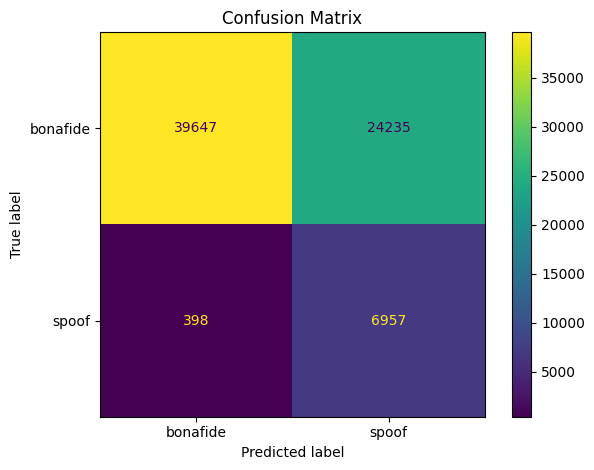

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = ["bonafide", "spoof"]

cm = confusion_matrix(act_labels, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format='d')

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=32a58f0bf706ef40dfc87efe2ed482f19ee876ca181b9481489031575bfec552
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=bc33e542a4ba889e58c9630356ea1ab58087896a7ca2e16e5a9ae1455d2862cd
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [22]:
# --------------------------------------------------------------
#  Model size & FLOPs (place this right after model creation)
# --------------------------------------------------------------
import torch
from torchinfo import summary
from fvcore.nn import FlopCountAnalysis, parameter_count

# --------------------------------------------------------------
# 1. Parameter count (trainable + non-trainable) + size in MiB
# --------------------------------------------------------------
def print_model_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    size_mb   = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024**2)

    print("\n" + "="*60)
    print("MODEL PARAMETER SUMMARY")
    print("="*60)
    print(f"{'Trainable params':<25}: {trainable:,}")
    print(f"{'Total params'    :<25}: {total:,}")
    print(f"{'Model size (MiB)':<25}: {size_mb:.2f}")
    print("="*60 + "\n")

print_model_params(model)

# --------------------------------------------------------------
# 2. FLOPs / MACs
# --------------------------------------------------------------
# We need a dummy waveform that matches the shape expected by the model.
#   - Rawformer_S expects raw audio: (batch, time)
#   - Use the maximum length defined in the config (or a typical 4-second clip)
max_len_sec = getattr(config, "max_len_sec", 2.0)          # fallback 4 s
max_samples = int(16000 * max_len_sec)

dummy_wav = torch.randn(1, max_samples, device=device)     # (B, T)

# Apply pre-emphasis if it is used in training/validation
# if pre is not None:
#     dummy_wav = pre(dummy_wav)

# ---- fvcore (very accurate) ----
flops = FlopCountAnalysis(model, dummy_wav)
macs  = flops.total()                # MACs = multiply-adds
flops_2 = macs * 2                   # FLOPs = 2 × MACs (standard convention)

print("\n" + "="*60)
print("FLOPs / MACs (per forward pass)")
print("="*60)
print(f"{'Input shape'   :<25}: {list(dummy_wav.shape)}")
print(f"{'MACs'          :<25}: {macs/1e9:.3f} G")
print(f"{'FLOPs'         :<25}: {flops_2/1e9:.3f} G")
print("="*60 + "\n")

# ---- torchinfo (nice table, optional) ----
print("Detailed layer-wise breakdown (torchinfo):")
summary(model,
        input_data=dummy_wav,
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        depth=4,
        verbose=1)

seconds = max_samples / 16000
print(f"GFLOPs per second of audio : {flops_2/1e9/seconds:.3f}")


MODEL PARAMETER SUMMARY
Trainable params         : 1,451,311
Total params             : 1,451,311
Model size (MiB)         : 5.54



Unsupported operator aten::clone encountered 1 time(s)
Unsupported operator aten::abs encountered 5 time(s)
Unsupported operator aten::max_pool2d encountered 7 time(s)
Unsupported operator aten::selu encountered 7 time(s)
Unsupported operator aten::add_ encountered 6 time(s)
Unsupported operator aten::add encountered 197 time(s)
Unsupported operator aten::mul encountered 331 time(s)
Unsupported operator aten::prelu encountered 45 time(s)
Unsupported operator aten::lt encountered 45 time(s)
Unsupported operator aten::sub encountered 540 time(s)
Unsupported operator aten::div encountered 280 time(s)
Unsupported operator aten::tanh encountered 10 time(s)
Unsupported operator aten::softmax encountered 10 time(s)
Unsupported operator aten::selu_ encountered 6 time(s)
Unsupported operator aten::sigmoid encountered 6 time(s)
Unsupported operator aten::topk encountered 6 time(s)
Unsupported operator aten::dropout_ encountered 7 time(s)
Unsupported operator aten::mean encountered 2 time(s)
The 


FLOPs / MACs (per forward pass)
Input shape              : [1, 32000]
MACs                     : 4.827 G
FLOPs                    : 9.653 G

Detailed layer-wise breakdown (torchinfo):
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Mult-Adds
DataParallel                                  [1, 32000]                [1, 2]                    --                        --
├─Model: 1-1                                  [1, 32000]                [1, 2]                    1,451,311                 --
├─Model: 1-2                                  --                        --                        --                        --
│    └─CONV: 2-1                              [1, 1, 32000]             [1, 70, 31872]            --                        --
│    └─BatchNorm2d: 2-2                       [1, 1, 23, 10624]         [1, 1, 23, 10624]         2                         2
│    └─SELU: 2-3                              [